#### European Ski Resorts - Machine Learning 

##### This notebook covers :
1. Adjusting EDA for machine learning models 
2. Training/Testing RandomForest Regression models 

Outputs (to be used for unsupervised learning): 
`ski_resorts_unsupervised.csv`

In [1]:
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:
# Using the 'Clean' csv as it contains the raw number for slopes count, as opposed to the 'Processed' csv which contains standardization of slope levels which machine learning models won't be able to use.
#  
df_processed = pd.read_csv('../data/ski_resorts_clean.csv')


#### Average Ticket price for Daypass(Adult)

In [3]:
len(df_processed[df_processed['TotalSlope']==0])
avg_dayPassPrice = round(np.average(df_processed['DayPassPriceAdult']),2)
print(f'Avg price for DayPass - Adult: ', avg_dayPassPrice)

Avg price for DayPass - Adult:  41.83


In [4]:
#checking dataframe for where 'TotalSlope' has value of 0. 
df_processed[df_processed['TotalSlope']==0]

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,VerticalDrop,resort_size_category
131,Sheregesh-Kemerovo,Siberia,1270,670,43.0,0,0,0,0,0,0,3,5,4,12,19919,0,600,Small
142,Aiguille du Midi-Chamonix-,France,3842,1035,60.0,0,0,0,0,0,0,0,0,5,5,4820,0,2807,Small
202,Indoor ski area Snow Dome Bispingen,Germany,122,90,37.0,0,0,0,0,1,1,2,1,0,3,3710,12,32,Small
294,Pischa (Davos Klosters),Switzerland,2483,1800,40.0,0,0,0,0,0,0,0,0,1,1,800,0,683,Small


#### Dropping the rows for where resorts 'TotalSlopes' have a value of 0

In [ ]:
# Keeping rows where 'TotalSlope' have a value other than 0. 
df_raw = df_processed[df_processed['TotalSlope'] != 0].reset_index(drop=True)

In [6]:
df_raw[['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope', 'TotalSlope', 'DayPassPriceAdult']]

,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,DayPassPriceAdult
0,30,81,4,115,52.0
1,100,77,33,210,47.0
2,1,0,1,2,30.0
3,15,33,3,51,42.0
4,30,26,21,77,22.0
...,...,...,...,...,...
359,96,220,84,400,48.0
360,96,220,84,400,48.0
361,23,94,15,132,43.0
362,23,94,15,132,43.0


In [7]:
df_raw.head()

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,VerticalDrop,resort_size_category
0,Alpendorf (Ski amedé),Austria,1980,740,52.0,30,81,4,115,1,0,22,16,11,49,75398,600,1240,Very Large
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47.0,100,77,33,210,1,1,37,28,7,72,99017,1032,930,Very Large
2,Oberau (Wildschönau),Austria,1130,900,30.0,1,0,1,2,0,0,2,0,0,2,1932,0,230,Small
3,Dachstein West,Austria,1620,780,42.0,15,33,3,51,1,1,25,8,3,36,32938,163,840,Large
4,Rosa Khutor,Southern Russia,2320,940,22.0,30,26,21,77,1,0,6,11,10,27,49228,450,1380,Large
5,Białka Tatrzańska-Kotelnica-​Kaniówka-​Bania,Poland,910,680,23.0,12,3,0,16,1,1,7,1,0,8,28020,0,230,Small
6,Vitosha-Sofia,Bulgaria,2290,726,18.0,12,6,2,20,0,1,8,5,2,15,12450,0,1564,Small
7,Szczyrk-Skrzyczne,Poland,1257,524,20.0,22,7,4,35,0,0,11,4,1,16,22500,0,733,Medium
8,Jahorina,Bosnia and Herzegovina,1889,920,20.0,3,19,3,25,0,1,5,5,1,11,16230,0,969,Small
9,Kobla-Bohinj,Slovenia,1480,540,22.0,12,10,1,23,0,0,3,3,0,6,5720,30,940,Small


#### Regression : Random Forest
We aim to analyze the question whether the number of slopes has any impact on DayPassPriceAdult. 

We selected Random Forest regression as we're trying to predict a continuous value (DayPassPrice) and were particularly drawn to this model due to its ability to use random subsets of data (bootstrap) in conjunction with being able to fit multiple decision trees. 

In [8]:
x = df_raw[['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope']].values
y = df_raw['DayPassPriceAdult'].values

Regression - Test/Split/Train 

For linear regression, the list of independent variables are: Beginner Slope, Intermediate Slope and Difficult Slope. I've omitted Total Slope as this value is just the sum of the independent variables. The target variable is: DayPassPrice Adult which is what we're trying to predict. 



In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, train_size=0.8, random_state=44)

In [10]:
regressor = RandomForestRegressor(n_estimators=100, random_state=99, verbose=True)

In [11]:
regressor.fit(x_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


RandomForestRegressor(random_state=99, verbose=True)

#### Signs of underfitting/overfitting
If both training and testing scores are low, that can indicate underfitting. The model is too simple and fails to detect any meaningful pattern in the data. 

**Overfitting**  

If there's a large gap between the high train R<sup>2</sup> score and low test R<sup>2</sup> score, that would be an indication that the model's failed on predicting unseen data,  and not able to generalize patterns (it learned the training data too well). 

The R <sup>2</sup> score meausres how well the model fits the actual data (train dataset) as well as on predictions on unseen data (test dataset) to see how well the predictions generalize.

In [55]:
train_score = round(regressor.score(x_train, y_train),4)
test_score = round(regressor.score(x_test, y_test),4)
print(f'Train Score:', train_score)
print(f'Test Score: ', test_score)



Train Score: 0.8846
Test Score:  0.2418


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


In [13]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x,y, test_size=0.2, train_size=0.8, random_state=44)

#### In the first round of running the model, we see the model overfits the data as evidenced by the high train R<sup>2</sup> score and low test R<sup>2</sup> score where it learned the training data too well. 

#### Adjusting Random Forest model - max depth
With the second iteration of running the model, I wanted to see if we changed max-depth to 3 and kept everything else the same, whether that would have any impact on the test and train scores. 

In [77]:
regressor_v1 = RandomForestRegressor(n_estimators=100, random_state=99, max_depth=3)
regressor_v1.fit(x1_train, y1_train)

RandomForestRegressor(max_depth=3, random_state=99)

In [88]:
train_score_v1 = round(regressor_v1.score(x1_train, y1_train),4)
test_score_v1 = round(regressor_v1.score(x1_test, y1_test),4)
print(f'Max Depth(3), Train Score:', train_score_v1)
print(f'Max Depth(3), Test Score: ', test_score_v1)

Max Depth(3), Train Score: 0.4955
Max Depth(3), Test Score:  0.3646


#### In the second iteration, we see a noticeable improvement in the test and train score such that both scores are relatively close to each other. This indicates that we no longer have overfitting though I would like to see the R<sup>2</sup> train and test scores to increase. 

#### I wanted to see if we experimented with varying levels of max_depth,  whether this would have any positive impact to train/test scores.

In [80]:
regressor_v2 = RandomForestRegressor(n_estimators=100, random_state=99, max_depth=5)
regressor_v2.fit(x1_train, y1_train)

RandomForestRegressor(max_depth=5, random_state=99)

In [82]:
# using .score() to calculate R2 score 
train_score_v2 = round(regressor_v2.score(x1_train, y1_train),4)
test_score_v2 = round(regressor_v2.score(x1_test, y1_test),4)
print(f'Max Depth (5): Train Score: ', train_score_v2)
print(f'Max Depth (5): Test Score', test_score_v2)

Max Depth (5): Train Score:  0.635
Max Depth (5): Test Score 0.32


In [83]:
regressor_v3 = RandomForestRegressor(n_estimators=100, random_state=99,  max_depth=7)
regressor_v3.fit(x1_train, y1_train)

RandomForestRegressor(max_depth=7, random_state=99)

In [84]:
train_score_v3 = round(regressor_v3.score(x1_train, y1_train),4)
test_score_v3 = round(regressor_v3.score(x1_test, y1_test),4)
print(f'Max Depth (7): Train Score', train_score_v3)
print(f'Max Depth (7): Test Score', test_score_v3)

Max Depth (7): Train Score 0.7438
Max Depth (7): Test Score 0.3004


In [85]:
regressor_v4 = RandomForestRegressor(n_estimators=100, random_state=99,  max_depth=2)
regressor_v4.fit(x1_train, y1_train)

RandomForestRegressor(max_depth=2, random_state=99)

In [87]:
train_score_v4 = round(regressor_v4.score(x1_train, y1_train),4)
test_score_v4 = round(regressor_v4.score(x1_test, y1_test),4)
print(f'Max Depth(2), Train Score:', train_score_v4)
print(f'Max Depth(2), Test Score: ' , test_score_v4)

Max Depth(2), Train Score: 0.4319
Max Depth(2), Test Score:  0.3814


In [93]:
regressor_v5 = RandomForestRegressor(n_estimators=100, random_state=99,  max_depth=1)
regressor_v5.fit(x1_train, y1_train)

RandomForestRegressor(max_depth=1, random_state=99)

In [94]:
train_score_v5 = round(regressor_v5.score(x1_train, y1_train),4)
test_score_v5 = round(regressor_v5.score(x1_test, y1_test),4)
print(f'Max Depth(1), Train Score:', train_score_v5)
print(f'Max Depth(1), Test Score: ', test_score_v5)

Max Depth(1), Train Score: 0.3317
Max Depth(1), Test Score:  0.3593


#### Random Forest : Train/Test Observations
After testing the varying `max_depth` levels , the optimal R<sup>2</sup> train and test scores were where max_depth = 2. 

Train score: 0.4319  
Test score: 0.3814

In [66]:
df_raw['Country'].value_counts()

Country
Austria                   89
France                    82
Switzerland               60
Italy                     44
Germany                   23
Norway                    10
Spain                      8
Sweden                     6
Andorra                    5
Slovakia                   5
Slovenia                   4
United Kingdom             4
Bulgaria                   4
Southern Russia            4
Finland                    3
Poland                     2
Czech Republic             2
Romania                    2
Lithuania                  1
Liechtenstein              1
Serbia                     1
Greece                     1
Bosnia and Herzegovina     1
Ukraine                    1
Netherlands                1
Name: count, dtype: int64

#### Experimenting with whether Test/Train R<sup>2</sup> scores would improve when we add Country specific information

In [ ]:
# Grouping countries to prep for one-hot encoding. This information was in the `ski_resorts_processed.csv but due to the slope zscale issue, I couldn't use CSV.`
counts = df_raw['Country'].value_counts()
df_raw['CountryGrouped'] = df_raw['Country'].where(df_raw['Country'].isin(counts[counts >= 5].index), 'Other')
country_dummies = pd.get_dummies(df_raw['CountryGrouped'], prefix='Country', dtype=int)

In [68]:
X_Country = pd.concat([df_raw[['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope']], country_dummies], axis=1).values

In [ ]:
#Incorporating country specific feature for test/train/split

x_train_Country, x_test_Country, y_train_Country, y_test_Country = train_test_split(X_Country, y, test_size=0.2, train_size=0.8, random_state=44)

In [102]:
regressor_country = RandomForestRegressor(n_estimators=100, max_depth=2, random_state=99)

In [103]:
regressor_country.fit(x_train_Country, y_train_Country)

RandomForestRegressor(max_depth=2, random_state=99)

In [104]:
train_score_country = round(regressor_country.score(x_train_Country, y_train_Country),4)
test_score_country = round(regressor_country.score(x_test_Country, y_test_Country),4)
print(f'Max Depth(3) + Country - Train Score: ', train_score_country)
print(f'Max Depth(3) + Country - Test Score: ', test_score_country)

Max Depth(3) + Country - Train Score:  0.5375
Max Depth(3) + Country - Test Score:  0.5677


In [111]:
# Testing whether n_estimators makes a difference while keeping all other factors constant

x_train_Country_reduced_estimator, x_test_Country_reduced_estimator, y_train_Country_reduced_estimator, y_test_Country_reduced_estimator = train_test_split(X_Country, y, test_size=0.2, train_size=0.8, random_state=44)

regressor_country_reduced_estimators = RandomForestRegressor(n_estimators=75, max_depth=5, random_state=99)
regressor_country_reduced_estimators.fit(x_train_Country_reduced_estimator, y_train_Country_reduced_estimator)


RandomForestRegressor(max_depth=5, n_estimators=75, random_state=99)

In [112]:
train_score_country_reduced_estimator = round(regressor_country_reduced_estimators.score(x_train_Country_reduced_estimator, y_train_Country_reduced_estimator),4)

test_score_country_reduced_estimator = round(regressor_country_reduced_estimators.score(x_test_Country, y_test_Country),4)
print(f'Max Depth(5) + Country - Train Score:', train_score_country_reduced_estimator)
print(f'Max Depth(5) + Country - Test Score: ', test_score_country_reduced_estimator)

Max Depth(5) + Country - Train Score: 0.7957
Max Depth(5) + Country - Test Score:  0.7342


#### Random Forest - Observations using country specific feature
When we added the country-specific feature to RandomForest regression model while keeping max_depth = 3, our test and training R<sup>2</sup> score increased:

Max Depth(3) + Country -  `0.5375`  
Max Depth(3) + Country -  `0.5677`  


However, when we further tested the model by decreasing n_estimators from 100 down to 75, and increased max depth=5, we observe a drastic increase to our R<sup>2</sup> test/train scores. 




In [33]:
importances = regressor_country.feature_importances_
feature_names = ['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope'] + list(country_dummies.columns)
importances_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
importances_df

,feature,importance
1,IntermediateSlope,0.525981
13,Country_Switzerland,0.287504
2,DifficultSlope,0.078198
0,BeginnerSlope,0.065884
4,Country_Austria,0.017074
5,Country_France,0.011524
6,Country_Germany,0.007715
9,Country_Other,0.006120
3,Country_Andorra,0.000000
7,Country_Italy,0.000000


#### Feature vs importance contribution 

In this chart we calculate how much each feature contribute to a model's variance reduction in how the decision trees splits to predict Daypass Price.  

IntermediateSlope (52.5%), Country_Switzerland (28.75%) accounts for `81.25%` of the model splitting process whereas DifficultSlope and BeginnerSlope have a combined ~`14%` weight in model decision-making process. 

In [34]:
y_pred = regressor_country.predict(x_test_Country)
y_true = y_test_Country
r2_country = round(r2_score(y_true, y_pred),4)

#### RMSE (Root Mean Squared Error): Just how far off the mark are predictions? 

#### When we incorporated the country encoded feature into the model, this resulted in a lower RMSE (6.33)

In [105]:
RMSE_country = round(root_mean_squared_error(y_true, y_pred),4)
print(f'RMSE: ', RMSE_country)

RMSE:  6.3308


#### Recall that our earlier iteration did not take country specific feature into account and this resulted in a higher RMSE

In [36]:
RMSE = round(root_mean_squared_error(y_true=y_test, y_pred=regressor_v4.predict(x1_test)),4)
print(RMSE)

8.2749


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


#### MAE - Mean Absolute Error : How accurate are the model's predictions?
MAE measures close the forecast is from the actual DayPassPrice values


In [106]:
mae_country = round(mean_absolute_error(y_true, y_pred),4)
print(f'MAE', mae_country)

MAE 4.9351


In [38]:
mae_baseline = round(mean_absolute_error(y_true=y_test, y_pred=regressor_v4.predict(x1_test)),4)
print(mae_baseline)

6.274


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


In [39]:
print(f'MAPE baseline:  {mae_baseline/avg_dayPassPrice:.1%}')

MAPE baseline:  15.0%


In [40]:
print(f'MAPE using Country dummies:  {mae_country/avg_dayPassPrice:.2%}')

MAPE using Country dummies:  11.80%


#### When we incorporated the country specific feature, that resulted in  MAE of 4.9351 vs MAE of 6.274 vs when we omitted this feature. 

#### <u>Mean Absolute Percentage Error (MAPE)</u>
In this case, when we implemented country dummies into the dataset and ran the model, the MAE was under 5. This metric tells us that we're off by 5 units (euros). 

**<u>The average price of DayPassPrice: EUR 41.83</u>**

If we divide the error by average price, this tells us how far off the mark percentage-wise of what we're predicting. 

Predictions using Country dummies resulted in a lower MAPE rate (`11.80%`) than if we just were to measuring the number of slopes in order to gauge how far off the mark on DayPass prices as seen in MAE_baseline (`15%`)

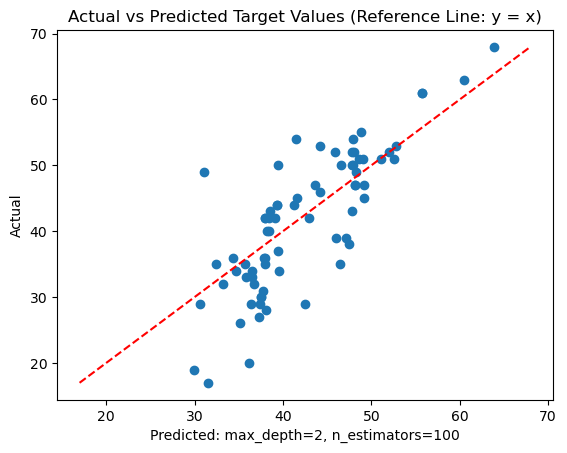

In [108]:

fig, ax = plt.subplots()
plt.scatter(x=y_pred, y=y_test_Country)

min_val = min(y_pred.min(), y_test_Country.min()) # min_val, max_val to calculate diagonal line
max_val = max(y_pred.max(), y_test_Country.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
ax.set_xlabel("Predicted: max_depth=2, n_estimators=100")
ax.set_ylabel("Actual")
ax.set_title('Actual vs Predicted Target Values (Reference Line: y = x)')
plt.show() 

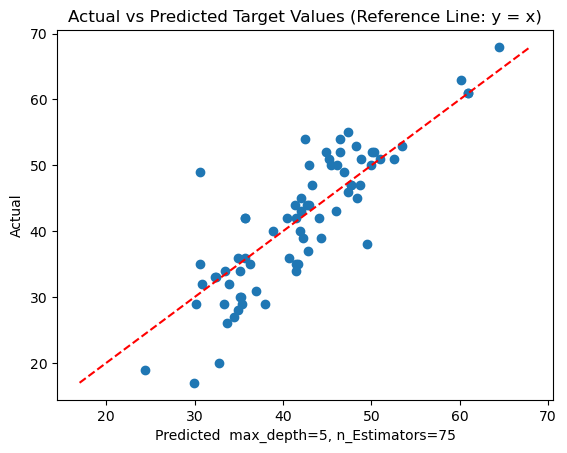

In [114]:

fig, ax = plt.subplots()
y_pred_reduced_estimators = regressor_country_reduced_estimators.predict(x_test_Country_reduced_estimator)
plt.scatter(x=y_pred_reduced_estimators, y=y_test_Country_reduced_estimator)

min_val = min(y_pred.min(), y_test_Country.min())
max_val = max(y_pred.max(), y_test_Country.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
ax.set_xlabel("Predicted  " \
"max_depth=5, n_Estimators=75")
ax.set_ylabel("Actual")
ax.set_title('Actual vs Predicted Target Values (Reference Line: y = x)')
plt.show() #max depth = 5

We observe that when we reduce n_estimators = 75 and increase max_depth=5, our data points are less spread out and hug the diagonal line more closely. Whereas in the plot for n_estimators=100 with max_depth=3, the data points are more spread out indicating less fit. 

#### Using GridSearch CV to tune model and optimize hyperparameters

In [43]:
grid = {
    'n_estimators': [40,50,60,70,80],
    'max_depth': [1,2,3,4,5],
    
}



In [44]:
GSC_CV = GridSearchCV(estimator=RandomForestRegressor(random_state=99), param_grid=grid, cv = 5, n_jobs = -1, scoring = 'r2', )

In [45]:
GSC_CV.fit(x_train_Country_reduced_estimator, y_train_Country_reduced_estimator)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=99), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4, 5],
                         'n_estimators': [40, 50, 60, 70, 80]},
             scoring='r2')

In [46]:
GSC_CV.best_params_

{'max_depth': 5, 'n_estimators': 80}

#### Rerunning model using optimimal hyperparameters

In [47]:
x_train_tuned, x_test_tuned, y_train_tuned, y_test_tuned = train_test_split(X_Country, y, test_size=0.2, train_size=0.8, random_state=44)

regressor_country_tuned = RandomForestRegressor(n_estimators=80, max_depth=5, random_state=99)
regressor_country_tuned.fit(x_train_tuned, y_train_tuned)

RandomForestRegressor(max_depth=5, n_estimators=80, random_state=99)

In [115]:
train_score_tuned = round(regressor_country_tuned.score(x_train_tuned, y_train_tuned),4)

test_score_tuned = round(regressor_country_tuned.score(x_test_tuned, y_test_tuned),4)

print(f'Optimal R2 - Train Score', train_score_tuned)
print(f'Optimal R2 - Test Score:', test_score_tuned)


Optimal R2 - Train Score 0.7957
Optimal R2 - Test Score: 0.7352


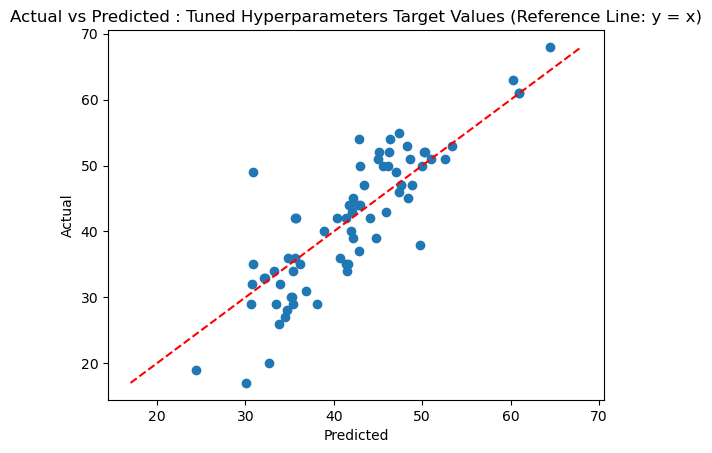

In [ ]:
#Using tuned hyperparameters (max_depth = 5, n_estimators = 80)

fig, ax = plt.subplots()
y_pred_optimal = regressor_country_tuned.predict(x_test_tuned)
plt.scatter(x=y_pred_optimal, y=y_test_tuned)

min_val = min(y_pred_optimal.min(), y_test_tuned.min())
max_val = max(y_pred_optimal.max(), y_test_tuned.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title('Actual vs Predicted : Tuned Hyperparameters Target Values (Reference Line: y = x)')
plt.show() 

#### With the tuned hyperparameters, we observe an accurate fit of data points between 40-60 as points cluster tightly around the y=x line showing solid prediction accuracy. However, at the 30-40, there's still some vertical scatter that could indicate underfitting. The model may lack key features to explain low pricing. 

#### Pearson's R - Determine level of correlation between slope level & price


In [50]:
correlation = df_raw['IntermediateSlope'].corr(df_raw['DayPassPriceAdult'],method='pearson')
print(correlation)

0.5720953928384261


#### Here, for Pearson's correlation coefficient (PCC) also known as Pearson's r, we have 0.572 which is an indication that there is a moderate linear correlation between Intermediate slope level and the Day pass price. 

#### <u>Key Findings</u>



#### Hypothesis

We observe that the Intermediate Slope level has a 52.59% feature importance in how the model determining its decision making process on predicting the Daypass price than beginner and advance slope combined.  Beginner & advance slope level have a combined importance of 14.40% in how it makes decisions to Daypass price. 

A plausible explanation as to why intermediate-level skiers dominate the majority segment of daypass price is that recreational skiers may be intermediate-level. If they're frequent skiers at ski resorts, they're most likely not beginners but they also may not be so advanced that they use the difficult slopes. 

We can't confirm from the data alone as the dataset captures resort facility amenities but not skier demographics or usage patterns. We can observe that intermediate slope level provides the strongest pattern for price predictor but can't confirm the underlying demand-side explanation without additional data. 



In [51]:
df_raw

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,VerticalDrop,resort_size_category,CountryGrouped
0,Alpendorf (Ski amedé),Austria,1980,740,52.0,30,81,4,115,1,0,22,16,11,49,75398,600,1240,Very Large,Austria
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47.0,100,77,33,210,1,1,37,28,7,72,99017,1032,930,Very Large,Andorra
2,Oberau (Wildschönau),Austria,1130,900,30.0,1,0,1,2,0,0,2,0,0,2,1932,0,230,Small,Austria
3,Dachstein West,Austria,1620,780,42.0,15,33,3,51,1,1,25,8,3,36,32938,163,840,Large,Austria
4,Rosa Khutor,Southern Russia,2320,940,22.0,30,26,21,77,1,0,6,11,10,27,49228,450,1380,Large,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,Montgenèvre (Via Lattea),France,2749,1372,48.0,96,220,84,400,0,1,29,35,7,71,96433,0,1377,Very Large,France
360,Sauze d’Oulx (Via Lattea),Italy,2749,1372,48.0,96,220,84,400,0,1,29,35,7,71,96433,0,1377,Very Large,Italy
361,Gressoney - La-Trinite (Monterosa Ski),Italy,3275,1212,43.0,23,94,15,132,1,0,9,9,12,30,31984,655,2063,Very Large,Italy
362,Champoluc (Monterosa Ski),Italy,3275,1212,43.0,23,94,15,132,1,0,9,9,12,30,31984,655,2063,Very Large,Italy


In [117]:
df_unsupervised = df_raw.to_csv('../data/ski_resorts_ML.csv', index=False)